In [ ]:
# =============
# CARGA DE LIBRERIAS

from astropy.io import fits
import gc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import pickle
import random
import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

C:\Z


In [ ]:
# =============
# CARGA DE DATASETS

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        # Cargamos el diccionario previamente guardado (.pt)
        data = torch.load(dataset_path)
        self.flux = data["flux"]          # Tensor con forma [N, num_points]
        self.wavelength = data["wavelength"]  # Tensor con forma [N, num_points]
        self.redshift = data["redshift"]      # Tensor con forma [N]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target

# Rutas a los archivos preprocesados
data_dir = "data"
train_dataset_path = os.path.join(data_dir, "train_dataset.pt")
test_dataset_path  = os.path.join(data_dir, "test_dataset.pt")

# Crear los datasets
train_dataset = SpectraDataset(train_dataset_path)
test_dataset  = SpectraDataset(test_dataset_path)

# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

Usando dispositivo: cuda


In [ ]:
# =============
# DEFINICIÓN Y CONFIGURACIÓN DEL MODELO

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Con 5 capas de max pooling, la dimensión se reduce en un factor de 2^5 = 32
        conv_output_size = num_points // 32
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * conv_output_size, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# Instanciar el modelo y moverlo a GPU si está disponible
modelCNN = CNN(num_points).to(device)
criterion = nn.L1Loss()
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print("Modelo configurado correctamente.")

Epoch 1/1000, Loss: 0.2709, Val Loss: 0.2467
Epoch 2/1000, Loss: 0.2615, Val Loss: 0.2460
Epoch 3/1000, Loss: 0.2703, Val Loss: 0.2441
Epoch 4/1000, Loss: 0.2617, Val Loss: 0.2411
Epoch 5/1000, Loss: 0.2560, Val Loss: 0.2403
Epoch 6/1000, Loss: 0.2544, Val Loss: 0.2418
Epoch 7/1000, Loss: 0.2570, Val Loss: 0.2367
Epoch 8/1000, Loss: 0.2513, Val Loss: 0.2344
Epoch 9/1000, Loss: 0.2495, Val Loss: 0.2339
Epoch 10/1000, Loss: 0.2499, Val Loss: 0.2321
Epoch 11/1000, Loss: 0.2460, Val Loss: 0.2303
Epoch 12/1000, Loss: 0.2448, Val Loss: 0.2326
Epoch 13/1000, Loss: 0.2461, Val Loss: 0.2305
Epoch 14/1000, Loss: 0.2437, Val Loss: 0.2258
Epoch 15/1000, Loss: 0.2432, Val Loss: 0.2280
Epoch 16/1000, Loss: 0.2401, Val Loss: 0.2242
Epoch 17/1000, Loss: 0.2410, Val Loss: 0.2237
Epoch 18/1000, Loss: 0.2385, Val Loss: 0.2264
Epoch 19/1000, Loss: 0.2425, Val Loss: 0.2234
Epoch 20/1000, Loss: 0.2358, Val Loss: 0.2214
Epoch 21/1000, Loss: 0.2347, Val Loss: 0.2195
Epoch 22/1000, Loss: 0.2344, Val Loss: 0.22

In [5]:
# # Cargar el modelo

# # Definir el directorio de destino
# output_dir = r'TFGF/Python/storage'
# model_file_path = os.path.join(output_dir, 'modelCNN_oldint.pth')

# modelCNN = CNN(num_points).to(device)
# modelCNN.load_state_dict(torch.load(model_file_path))

Redshift real: 0.65241706
Redshift predicho: 0.2677574157714844


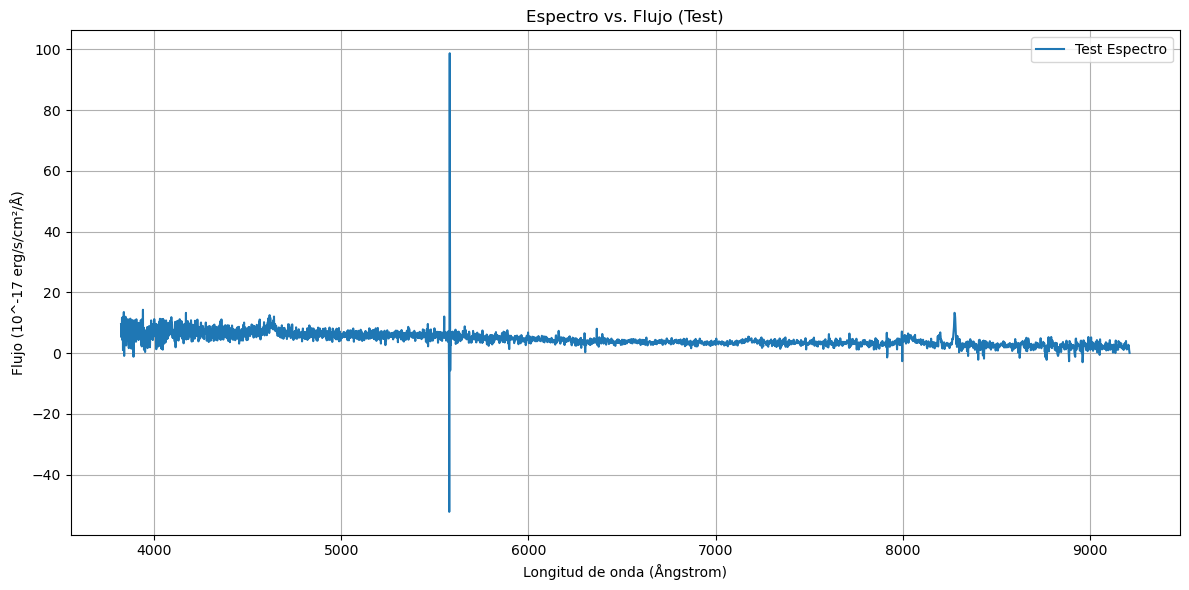

In [6]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from astropy.io import fits
import os
import matplotlib.pyplot as plt

file_path = r'TFGF/Python/spectrums/spec-0266-51630-0003.fits'

with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]  # Asumiendo que Z es un array y queremos el primer valor

test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    wl = list(wavelength)
    fl = list(flux)
    while len(wl) < target_count:
        diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl) - 1)]
        max_idx = np.argmax(diffs)
        new_wl = (wl[max_idx] + wl[max_idx+1]) / 2
        new_fl = (fl[max_idx] + fl[max_idx+1]) / 2
        wl.insert(max_idx+1, new_wl)
        fl.insert(max_idx+1, new_fl)
    return np.array(wl), np.array(fl)

test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=num_points)

# Preprocesamiento para el modelo
# Canal 0: flux; Canal 1: wavelength
input_data = np.stack([test_flux, test_wavelength], axis=0)  # (2, 5000) 2 canales de tamaño 5000
input_data = input_data.reshape(1, 2, num_points)            # (1, 2, 5000) 1 muestra, 2 canales, 5000 puntos/canal

# Normalización
nsamples, nchannels, npoints = input_data.shape # Guardar dimensionalidad inicial
input_flat = input_data.reshape(nsamples, -1) # Aplanar/concatenar (1, 10000)
input_scaled = scaler.transform(input_flat) # Normalizar
input_scaled = input_scaled.reshape(nsamples, nchannels, npoints) # Recuperar dimensionalidad incial

# Convertir a tensor
input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
input_tensor = input_tensor.to(device)

# Evaluar el modelo
with torch.no_grad():
    predicted_redshift = modelCNN(input_tensor)

print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Test Espectro")
plt.xlabel("Longitud de onda (Ångstrom)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro vs. Flujo (Test)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()